#HW08-09 – PyTorch MLP: регуляризация и оптимизация обучения

In [95]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


* Импорты и общие настройки

In [96]:
import os
import math
import random
from dataclasses import dataclass, asdict
from typing import Dict, Any, Tuple, Optional, List
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import csv
import torch.optim as optim

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

# Для Windows: num_workers=0 по умолчанию (чтобы избежать проблем с multiprocessing)
DEFAULT_NUM_WORKERS = 0

# Быстрый режим (рекомендуется для семинара/проверки)
FAST_MODE = True

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def maybe_subset(ds, max_items: Optional[int], seed: int = 42):
    if max_items is None:
        return ds
    n = len(ds)
    if max_items >= n:
        return ds
    rng = np.random.default_rng(seed)
    idx = rng.choice(n, size=max_items, replace=False)
    return Subset(ds, idx.tolist())

set_seed(42)
device = get_device()
device

# Определяем устройство (GPU, если доступно)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

# Создаем директории для артефактов на Google Drive
drive_path = "/content/drive/MyDrive/Colab Notebooks/HW08-09/artifacts"
artifacts_dir = Path(drive_path)
figures_dir = artifacts_dir / "figures"

# Создаем папки (существующие не перезаписываются)
artifacts_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print(f"Артефакты будут сохраняться в: {artifacts_dir}")
print(f"Графики будут сохраняться в: {figures_dir}")

Используемое устройство: cpu
Артефакты будут сохраняться в: /content/drive/MyDrive/Colab Notebooks/HW08-09/artifacts
Графики будут сохраняться в: /content/drive/MyDrive/Colab Notebooks/HW08-09/artifacts/figures


# Загрузка данных


In [97]:
def load_dataset(name: str = "KMNIST", fast_mode: bool = True):
    """Загружает датасет через torchvision. Если torchvision недоступен – fallback на sklearn digits."""
    try:
        import torchvision
        from torchvision import transforms
        from torchvision.datasets import KMNIST, EMNIST, CIFAR10

        # лимиты под FAST_MODE
        max_train = 12000 if fast_mode else None
        max_test  = 3000 if fast_mode else None

        if name.upper() == "KMNIST":
            transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize((0.5,), (0.5,))
            ])
            ds_train = KMNIST(root="./data", train=True, download=True, transform=transform)
            ds_test  = KMNIST(root="./data", train=False, download=True, transform=transform)
            ds_train = maybe_subset(ds_train, max_train, seed=42)
            ds_test  = maybe_subset(ds_test, max_test, seed=43)
            input_shape = (1, 28, 28)
            num_classes = 10
            return ds_train, ds_test, input_shape, num_classes, f"{name} (torchvision)"

        if name.upper() == "EMNIST_BALANCED":
            transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize((0.5,), (0.5,))
            ])
            ds_train = EMNIST(root="./data", split="balanced", train=True, download=True, transform=transform)
            ds_test  = EMNIST(root="./data", split="balanced", train=False, download=True, transform=transform)
            ds_train = maybe_subset(ds_train, max_train, seed=42)
            ds_test  = maybe_subset(ds_test, max_test, seed=43)
            input_shape = (1, 28, 28)
            num_classes = len(getattr(ds_train, "dataset", ds_train).classes)  # учитываем Subset
            return ds_train, ds_test, input_shape, num_classes, f"{name} (torchvision)"

        if name.upper() == "CIFAR10":
            transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
            ])
            ds_train = CIFAR10(root="./data", train=True, download=True, transform=transform)
            ds_test  = CIFAR10(root="./data", train=False, download=True, transform=transform)
            ds_train = maybe_subset(ds_train, max_train, seed=42)
            ds_test  = maybe_subset(ds_test, max_test, seed=43)
            input_shape = (3, 32, 32)
            num_classes = 10
            return ds_train, ds_test, input_shape, num_classes, f"{name} (torchvision)"

        raise ValueError(f"Unknown dataset name: {name}")

    except Exception as e:
        print("torchvision недоступен или возникла ошибка загрузки. Fallback на sklearn.load_digits.")
        print("Причина:", repr(e))
        from sklearn.datasets import load_digits
        digits = load_digits()
        X = digits.images.astype(np.float32) / 16.0  # [0..1]
        y = digits.target.astype(np.int64)

        class DigitsDataset(torch.utils.data.Dataset):
            def __init__(self, X, y):
                self.X = torch.tensor(X).unsqueeze(1)  # (N,1,8,8)
                self.y = torch.tensor(y)
            def __len__(self): return self.X.shape[0]
            def __getitem__(self, idx): return self.X[idx], self.y[idx]

        ds_full = DigitsDataset(X, y)
        # split: 80/20
        n = len(ds_full)
        n_train = int(0.8 * n)
        n_test = n - n_train
        ds_train, ds_test = random_split(ds_full, [n_train, n_test], generator=torch.Generator().manual_seed(42))

        if fast_mode:
            ds_train = maybe_subset(ds_train, 1200, seed=42)
            ds_test  = maybe_subset(ds_test, 400, seed=43)

        input_shape = (1, 8, 8)
        num_classes = 10
        return ds_train, ds_test, input_shape, num_classes, "sklearn.load_digits (fallback)"

ds_train_full, ds_test, input_shape, num_classes, ds_name = load_dataset("EMNIST_BALANCED", fast_mode=FAST_MODE)
ds_name, input_shape, num_classes, len(ds_train_full), len(ds_test)

('EMNIST_BALANCED (torchvision)', (1, 28, 28), 47, 12000, 3000)

# Разбиение train/val и DataLoader

In [98]:
def make_loaders(ds_train_full, ds_test, batch_size: int = 128, val_ratio: float = 0.2, seed: int = 42):
    n_total = len(ds_train_full)
    n_val = max(1, int(n_total * val_ratio))
    n_train = n_total - n_val

    gen = torch.Generator().manual_seed(seed)
    ds_train, ds_val = random_split(ds_train_full, [n_train, n_val], generator=gen)

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=DEFAULT_NUM_WORKERS, pin_memory=torch.cuda.is_available())
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=DEFAULT_NUM_WORKERS, pin_memory=torch.cuda.is_available())
    test_loader  = DataLoader(ds_test, batch_size=batch_size, shuffle=False, num_workers=DEFAULT_NUM_WORKERS, pin_memory=torch.cuda.is_available())
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(ds_train_full, ds_test, batch_size=128)

# sanity-check
x, y = next(iter(train_loader))
x.shape, y.shape, x.min().item(), x.max().item()

(torch.Size([128, 1, 28, 28]), torch.Size([128]), -1.0, 1.0)

# Посмотрим на несколько примеров

Images shape: torch.Size([128, 1, 28, 28])
Labels shape: torch.Size([128])
Уникальные классы в батче: tensor([ 0,  2,  3,  4,  5,  6,  7,  9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20,
        21, 22, 23, 24, 25, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 39, 40,
        41, 42, 43, 44, 45, 46])


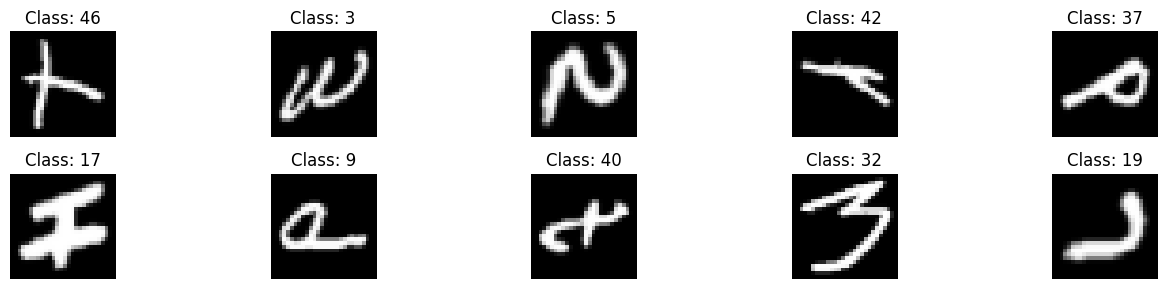

In [99]:
# Получаем один батч из train_loader
images, labels = next(iter(train_loader))

print(f"Images shape: {images.shape}")  # [batch_size, 1, 28, 28]
print(f"Labels shape: {labels.shape}")  # [batch_size]
print(f"Уникальные классы в батче: {torch.unique(labels)}")

# Визуализация первых 10 изображений
plt.figure(figsize=(14, 3))
for i in range(10):
    plt.subplot(2, 5, i+1)
    img = images[i].squeeze().cpu().numpy()
    # Обратная нормализация для отображения (для KMNIST мы использовали mean=0.5, std=0.5)
    img = img * 0.5 + 0.5
    plt.imshow(img, cmap='gray')
    plt.title(f"Class: {labels[i].item()}")
    plt.axis('off')
plt.tight_layout()
plt.show()



# Модель: MLP

In [100]:
class MLP(nn.Module):
    def __init__(
        self,
        input_shape: tuple,
        num_classes: int,
        hidden_sizes: List[int] = [256, 128],
        activation: str = "relu",
        dropout: float = 0.0,
        use_batchnorm: bool = False
    ):
        super().__init__()

        # Определяем функцию активации
        if activation.lower() == "relu":
            act_layer = nn.ReLU
        elif activation.lower() == "tanh":
            act_layer = nn.Tanh
        elif activation.lower() == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Неизвестная активация: {activation}")

        # Собираем слои
        layers = [nn.Flatten()]  # Превращаем 28x28 в вектор 784

        prev_size = input_shape[0] * input_shape[1] * input_shape[2]  # 1*28*28 = 784

        for i, hidden in enumerate(hidden_sizes):
            layers.append(nn.Linear(prev_size, hidden))

            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden))

            layers.append(act_layer())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            prev_size = hidden

        # Выходной слой (без активации - CrossEntropyLoss сам применит softmax)
        layers.append(nn.Linear(prev_size, num_classes))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Функции для обучения и валидации
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # Включаем режим обучения (важно для Dropout/BatchNorm)
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        _, predicted = torch.max(outputs, 1)
        total_correct += (predicted == y).sum().item()
        total_samples += x.size(0)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return avg_loss, accuracy

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  # Включаем режим оценки (Dropout/BatchNorm ведут себя иначе)
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        outputs = model(x)
        loss = criterion(outputs, y)

        total_loss += loss.item() * x.size(0)
        _, predicted = torch.max(outputs, 1)
        total_correct += (predicted == y).sum().item()
        total_samples += x.size(0)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return avg_loss, accuracy

def plot_training_history(history, title=""):
    """Рисует графики обучения"""
    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    # График loss
    ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    ax1.plot(epochs, history['val_loss'], 'r-', label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()
    ax1.grid(True)

    # График accuracy
    ax2.plot(epochs, history['train_acc'], 'b-', label='Train Acc')
    ax2.plot(epochs, history['val_acc'], 'r-', label='Val Acc')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Тестируем модель
test_model = MLP(
    input_shape=(1, 28, 28),
    num_classes=47,
    hidden_sizes=[256, 128],
    activation="relu",
    dropout=0.0,
    use_batchnorm=False
).to(device)

# Проверяем, что forward работает
x_batch, y_batch = next(iter(train_loader))
x_batch = x_batch.to(device)
output = test_model(x_batch)
print(f"Вход: {x_batch.shape} -> Выход: {output.shape}")

Вход: torch.Size([128, 1, 28, 28]) -> Выход: torch.Size([128, 47])


# Эксперимент E1 - Базовая модель (без регуляризации)

Артефакты будут сохраняться в: /content/drive/MyDrive/Colab Notebooks/HW08-09/artifacts
Эксперимент E1: Базовая модель (без регуляризации)
Эпоха  1/15 | Train Loss: 2.6491, Acc: 0.3106 | Val Loss: 1.8109, Acc: 0.4942
Эпоха  2/15 | Train Loss: 1.5363, Acc: 0.5604 | Val Loss: 1.4524, Acc: 0.5783
Эпоха  3/15 | Train Loss: 1.2963, Acc: 0.6235 | Val Loss: 1.3053, Acc: 0.6250
Эпоха  4/15 | Train Loss: 1.1635, Acc: 0.6566 | Val Loss: 1.2173, Acc: 0.6408
Эпоха  5/15 | Train Loss: 1.0496, Acc: 0.6909 | Val Loss: 1.1416, Acc: 0.6675
Эпоха  6/15 | Train Loss: 0.9574, Acc: 0.7122 | Val Loss: 1.1009, Acc: 0.6737
Эпоха  7/15 | Train Loss: 0.8740, Acc: 0.7370 | Val Loss: 1.0386, Acc: 0.6804
Эпоха  8/15 | Train Loss: 0.8012, Acc: 0.7573 | Val Loss: 0.9779, Acc: 0.7067
Эпоха  9/15 | Train Loss: 0.7317, Acc: 0.7705 | Val Loss: 0.9408, Acc: 0.7171
Эпоха 10/15 | Train Loss: 0.6729, Acc: 0.7882 | Val Loss: 0.9036, Acc: 0.7258
Эпоха 11/15 | Train Loss: 0.6269, Acc: 0.8005 | Val Loss: 0.8939, Acc: 0.7225
Эпо

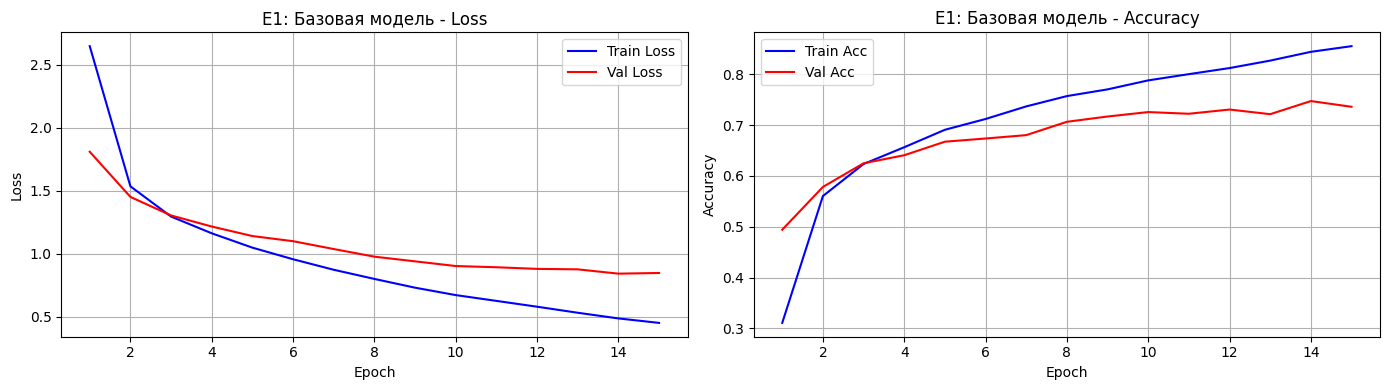

In [101]:
# Функция для сохранения результатов в CSV
def save_run_to_csv(run_data, filename=artifacts_dir / "runs.csv"):
    """Сохраняет результаты эксперимента в CSV файл"""
    file_exists = Path(filename).exists()

    with open(filename, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=run_data.keys())
        if not file_exists:
            writer.writeheader()
        writer.writerow(run_data)

# Путь для сохранения артефактов на Google Drive
artifacts_dir = Path("/content/drive/MyDrive/Colab Notebooks/HW08-09/artifacts")
figures_dir = artifacts_dir / "figures"

# Создаем папки, если их нет
artifacts_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print(f"Артефакты будут сохраняться в: {artifacts_dir}")

# Параметры эксперимента E1
EPOCHS = 15

print("="*50)
print("Эксперимент E1: Базовая модель (без регуляризации)")
print("="*50)

# Создаем модель
model_e1 = MLP(
    input_shape=(1, 28, 28),
    num_classes=47,
    hidden_sizes=[256, 128],
    activation="relu",
    dropout=0.0,          # Без Dropout
    use_batchnorm=False    # Без BatchNorm
).to(device)

# Определяем функцию потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_e1.parameters(), lr=0.001)

# История обучения
history_e1 = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

# Обучаем модель
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model_e1, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model_e1, val_loader, criterion, device)

    history_e1['train_loss'].append(train_loss)
    history_e1['train_acc'].append(train_acc)
    history_e1['val_loss'].append(val_loss)
    history_e1['val_acc'].append(val_acc)

    print(f"Эпоха {epoch:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

# Находим лучший результат на валидации
best_val_acc_e1 = max(history_e1['val_acc'])
best_epoch_e1 = history_e1['val_acc'].index(best_val_acc_e1) + 1
best_val_loss_e1 = history_e1['val_loss'][best_epoch_e1 - 1]

print(f"\nЛучший результат E1:")
print(f"Эпоха {best_epoch_e1}: Val Acc = {best_val_acc_e1:.4f}, Val Loss = {best_val_loss_e1:.4f}")

# Сохраняем результаты в CSV
run_data_e1 = {
    'experiment_id': 'E1',
    'dataset': 'EMNIST',
    'seed': 42,
    'model_summary': 'hidden=[256,128], relu, dropout=0.0, batchnorm=False',
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': '',
    'weight_decay': 0.0,
    'epochs_trained': EPOCHS,
    'best_val_accuracy': f"{best_val_acc_e1:.4f}",
    'best_val_loss': f"{best_val_loss_e1:.4f}"
}

save_run_to_csv(run_data_e1)
print(f"\nРезультаты сохранены в {artifacts_dir / 'runs.csv'}")

# Рисуем графики
plot_training_history(history_e1, title="E1: Базовая модель")

# Эксперимент E2 - Модель с Dropout


Эксперимент E2: Модель с Dropout (p=0.3)
Эпоха  1/15 | Train Loss: 3.1743, Acc: 0.1785 | Val Loss: 2.0878, Acc: 0.4562
Эпоха  2/15 | Train Loss: 2.0434, Acc: 0.4170 | Val Loss: 1.5685, Acc: 0.5567
Эпоха  3/15 | Train Loss: 1.6915, Acc: 0.5057 | Val Loss: 1.3549, Acc: 0.6083
Эпоха  4/15 | Train Loss: 1.5082, Acc: 0.5551 | Val Loss: 1.2747, Acc: 0.6196
Эпоха  5/15 | Train Loss: 1.3943, Acc: 0.5856 | Val Loss: 1.1642, Acc: 0.6625
Эпоха  6/15 | Train Loss: 1.3122, Acc: 0.6044 | Val Loss: 1.1144, Acc: 0.6596
Эпоха  7/15 | Train Loss: 1.2289, Acc: 0.6298 | Val Loss: 1.0637, Acc: 0.6854
Эпоха  8/15 | Train Loss: 1.1698, Acc: 0.6515 | Val Loss: 1.0303, Acc: 0.6854
Эпоха  9/15 | Train Loss: 1.1270, Acc: 0.6506 | Val Loss: 1.0109, Acc: 0.6921
Эпоха 10/15 | Train Loss: 1.0863, Acc: 0.6676 | Val Loss: 0.9822, Acc: 0.6992
Эпоха 11/15 | Train Loss: 1.0430, Acc: 0.6741 | Val Loss: 0.9598, Acc: 0.7079
Эпоха 12/15 | Train Loss: 1.0121, Acc: 0.6797 | Val Loss: 0.9340, Acc: 0.7233
Эпоха 13/15 | Train Lo

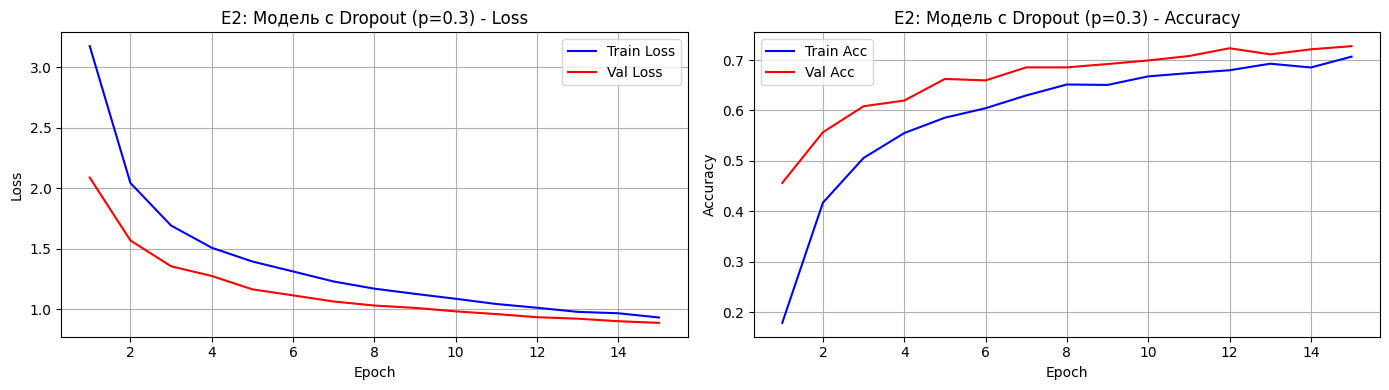


Сравнение результатов E1 vs E2:
E1 (базовая) - Val Acc: 0.7475
E2 (Dropout)  - Val Acc: 0.7275
Улучшение: -2.00%


In [102]:
print("\n" + "="*50)
print("Эксперимент E2: Модель с Dropout (p=0.3)")
print("="*50)

# Создаем модель с Dropout
model_e2 = MLP(
    input_shape=(1, 28, 28),
    num_classes=47,  # EMNIST Balanced = 47 классов
    hidden_sizes=[256, 128],
    activation="relu",
    dropout=0.3,          # Добавляем Dropout 30%
    use_batchnorm=False    # Без BatchNorm
).to(device)

# Определяем функцию потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_e2.parameters(), lr=0.001)

# История обучения
history_e2 = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

# Обучаем модель
EPOCHS = 15
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model_e2, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model_e2, val_loader, criterion, device)

    history_e2['train_loss'].append(train_loss)
    history_e2['train_acc'].append(train_acc)
    history_e2['val_loss'].append(val_loss)
    history_e2['val_acc'].append(val_acc)

    print(f"Эпоха {epoch:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

# Находим лучший результат на валидации
best_val_acc_e2 = max(history_e2['val_acc'])
best_epoch_e2 = history_e2['val_acc'].index(best_val_acc_e2) + 1
best_val_loss_e2 = history_e2['val_loss'][best_epoch_e2 - 1]

print(f"\nЛучший результат E2:")
print(f"Эпоха {best_epoch_e2}: Val Acc = {best_val_acc_e2:.4f}, Val Loss = {best_val_loss_e2:.4f}")

# Сохраняем результаты в CSV
run_data_e2 = {
    'experiment_id': 'E2',
    'dataset': 'EMNIST_BALANCED',
    'seed': 42,
    'model_summary': 'hidden=[256,128], relu, dropout=0.3, batchnorm=False',
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': '',
    'weight_decay': 0.0,
    'epochs_trained': EPOCHS,
    'best_val_accuracy': f"{best_val_acc_e2:.4f}",
    'best_val_loss': f"{best_val_loss_e2:.4f}"
}

save_run_to_csv(run_data_e2)
print(f"\nРезультаты сохранены в {artifacts_dir / 'runs.csv'}")

# Рисуем графики
plot_training_history(history_e2, title="E2: Модель с Dropout (p=0.3)")

# Сравнение с базовой моделью
print("\n" + "="*50)
print("Сравнение результатов E1 vs E2:")
print("="*50)
print(f"E1 (базовая) - Val Acc: {best_val_acc_e1:.4f}")
print(f"E2 (Dropout)  - Val Acc: {best_val_acc_e2:.4f}")
print(f"Улучшение: {((best_val_acc_e2 - best_val_acc_e1) * 100):.2f}%")

# Эксперимент E3 - Модель с BatchNorm


Эксперимент E3: Модель с BatchNorm
Эпоха  1/15 | Train Loss: 2.4246, Acc: 0.4684 | Val Loss: 1.6670, Acc: 0.5979
Эпоха  2/15 | Train Loss: 1.2763, Acc: 0.6972 | Val Loss: 1.2187, Acc: 0.6600
Эпоха  3/15 | Train Loss: 0.8730, Acc: 0.7666 | Val Loss: 1.0210, Acc: 0.7017
Эпоха  4/15 | Train Loss: 0.6640, Acc: 0.8101 | Val Loss: 0.8990, Acc: 0.7304
Эпоха  5/15 | Train Loss: 0.5174, Acc: 0.8542 | Val Loss: 0.8793, Acc: 0.7271
Эпоха  6/15 | Train Loss: 0.4218, Acc: 0.8774 | Val Loss: 0.7817, Acc: 0.7612
Эпоха  7/15 | Train Loss: 0.3452, Acc: 0.8982 | Val Loss: 0.7869, Acc: 0.7621
Эпоха  8/15 | Train Loss: 0.2868, Acc: 0.9191 | Val Loss: 0.7589, Acc: 0.7704
Эпоха  9/15 | Train Loss: 0.2420, Acc: 0.9304 | Val Loss: 0.8010, Acc: 0.7546
Эпоха 10/15 | Train Loss: 0.2069, Acc: 0.9404 | Val Loss: 0.8157, Acc: 0.7608
Эпоха 11/15 | Train Loss: 0.1825, Acc: 0.9477 | Val Loss: 0.8387, Acc: 0.7362
Эпоха 12/15 | Train Loss: 0.1531, Acc: 0.9572 | Val Loss: 0.8021, Acc: 0.7575
Эпоха 13/15 | Train Loss: 0.

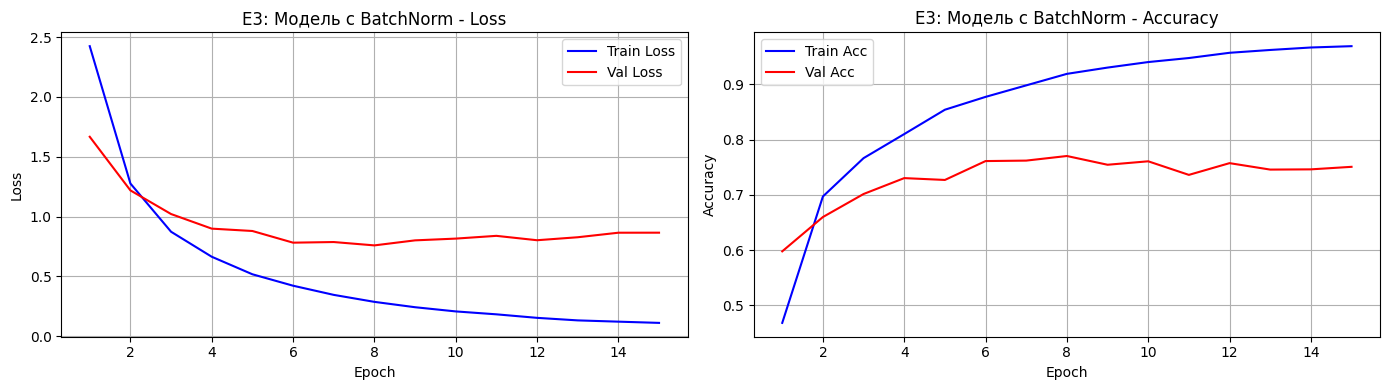


Сравнение результатов E1 vs E2 vs E3:
E1 (базовая)      - Val Acc: 0.7475
E2 (Dropout)      - Val Acc: 0.7275
E3 (BatchNorm)    - Val Acc: 0.7704

Лучшая модель: E3 (BatchNorm) с Val Acc = 0.7704


In [103]:
print("\n" + "="*50)
print("Эксперимент E3: Модель с BatchNorm")
print("="*50)

# Создаем модель с BatchNorm
model_e3 = MLP(
    input_shape=(1, 28, 28),
    num_classes=47,  # EMNIST Balanced = 47 классов
    hidden_sizes=[256, 128],
    activation="relu",
    dropout=0.0,           # Без Dropout
    use_batchnorm=True     # Добавляем BatchNorm
).to(device)

# Определяем функцию потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_e3.parameters(), lr=0.001)

# История обучения
history_e3 = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

# Обучаем модель
EPOCHS = 15
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model_e3, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model_e3, val_loader, criterion, device)

    history_e3['train_loss'].append(train_loss)
    history_e3['train_acc'].append(train_acc)
    history_e3['val_loss'].append(val_loss)
    history_e3['val_acc'].append(val_acc)

    print(f"Эпоха {epoch:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

# Находим лучший результат на валидации
best_val_acc_e3 = max(history_e3['val_acc'])
best_epoch_e3 = history_e3['val_acc'].index(best_val_acc_e3) + 1
best_val_loss_e3 = history_e3['val_loss'][best_epoch_e3 - 1]

print(f"\nЛучший результат E3:")
print(f"Эпоха {best_epoch_e3}: Val Acc = {best_val_acc_e3:.4f}, Val Loss = {best_val_loss_e3:.4f}")

# Сохраняем результаты в CSV
run_data_e3 = {
    'experiment_id': 'E3',
    'dataset': 'EMNIST_BALANCED',
    'seed': 42,
    'model_summary': 'hidden=[256,128], relu, dropout=0.0, batchnorm=True',
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': '',
    'weight_decay': 0.0,
    'epochs_trained': EPOCHS,
    'best_val_accuracy': f"{best_val_acc_e3:.4f}",
    'best_val_loss': f"{best_val_loss_e3:.4f}"
}

save_run_to_csv(run_data_e3)
print(f"\nРезультаты сохранены в {artifacts_dir / 'runs.csv'}")

# Рисуем графики
plot_training_history(history_e3, title="E3: Модель с BatchNorm")

# Сравнение всех трех моделей
print("\n" + "="*50)
print("Сравнение результатов E1 vs E2 vs E3:")
print("="*50)
print(f"E1 (базовая)      - Val Acc: {best_val_acc_e1:.4f}")
print(f"E2 (Dropout)      - Val Acc: {best_val_acc_e2:.4f}")
print(f"E3 (BatchNorm)    - Val Acc: {best_val_acc_e3:.4f}")

# Определяем лучшую модель для E4
best_val = max(best_val_acc_e1, best_val_acc_e2, best_val_acc_e3)
if best_val == best_val_acc_e2:
    print(f"\nЛучшая модель: E2 (Dropout) с Val Acc = {best_val_acc_e2:.4f}")
    best_config_for_e4 = 'Dropout'
elif best_val == best_val_acc_e3:
    print(f"\nЛучшая модель: E3 (BatchNorm) с Val Acc = {best_val_acc_e3:.4f}")
    best_config_for_e4 = 'BatchNorm'
else:
    print(f"\nЛучшая модель: E1 (базовая) с Val Acc = {best_val_acc_e1:.4f}")
    best_config_for_e4 = 'Base'

# Эксперимент E4 - Лучшая модель с Early Stopping


Артефакты будут сохраняться в локальную папку: /content/artifacts

Эксперимент E4: Лучшая модель с Early Stopping
Используем конфигурацию с Dropout (как в E2)
Эпоха  1/30 | Train Loss: 3.0730, Acc: 0.2014 | Val Loss: 2.0118, Acc: 0.4971
  → Новая лучшая модель! Val Acc = 0.4971
Эпоха  2/30 | Train Loss: 1.9949, Acc: 0.4278 | Val Loss: 1.5219, Acc: 0.5742
  → Новая лучшая модель! Val Acc = 0.5742
Эпоха  3/30 | Train Loss: 1.6556, Acc: 0.5181 | Val Loss: 1.3277, Acc: 0.6292
  → Новая лучшая модель! Val Acc = 0.6292
Эпоха  4/30 | Train Loss: 1.4876, Acc: 0.5637 | Val Loss: 1.2511, Acc: 0.6404
  → Новая лучшая модель! Val Acc = 0.6404
Эпоха  5/30 | Train Loss: 1.3670, Acc: 0.5896 | Val Loss: 1.1734, Acc: 0.6471
  → Новая лучшая модель! Val Acc = 0.6471
Эпоха  6/30 | Train Loss: 1.2595, Acc: 0.6172 | Val Loss: 1.1055, Acc: 0.6613
  → Новая лучшая модель! Val Acc = 0.6613
Эпоха  7/30 | Train Loss: 1.2080, Acc: 0.6345 | Val Loss: 1.0527, Acc: 0.6871
  → Новая лучшая модель! Val Acc = 0.6871


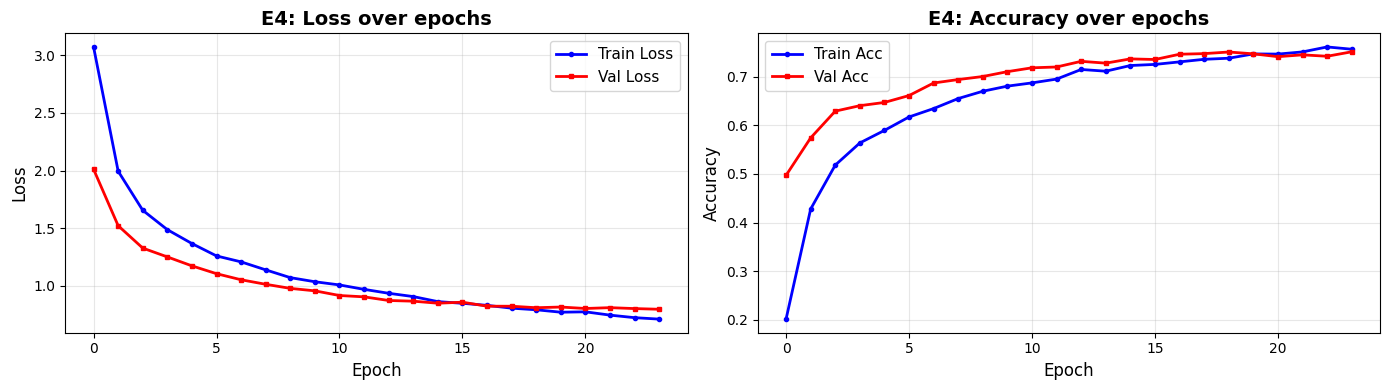


СКАЧИВАНИЕ ФАЙЛОВ НА КОМПЬЮТЕР
Скачивание runs.csv...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Скачивание best_model.pt...


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Скачивание curves_best.png...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Все файлы успешно скачаны!
История обучения сохранена в artifacts/history_e4.pkl

Эксперимент E4 завершен!
Все файлы сохранены в папке: /content/artifacts


In [104]:
# Шаг 7: Эксперимент E4 - Лучшая модель с Early Stopping

import os
import pickle
import matplotlib.pyplot as plt
from pathlib import Path
from google.colab import files  # Добавляем импорт для скачивания

# Создаем локальную папку для артефактов
local_artifacts_dir = Path("./artifacts")
local_figures_dir = local_artifacts_dir / "figures"
local_artifacts_dir.mkdir(parents=True, exist_ok=True)
local_figures_dir.mkdir(parents=True, exist_ok=True)

print(f"\nАртефакты будут сохраняться в локальную папку: {local_artifacts_dir.absolute()}")

class EarlyStopping:
    """Ранняя остановка обучения"""
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, val_acc, model):
        if self.best_score is None:
            self.best_score = val_acc
            self.best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        elif val_acc < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_acc
            self.best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
        return self.early_stop

print("\n" + "="*50)
print("Эксперимент E4: Лучшая модель с Early Stopping")
print("="*50)

# Используем лучшую конфигурацию из предыдущих экспериментов
print("Используем конфигурацию с Dropout (как в E2)")

# Создаем модель (как в E2 - с Dropout)
model_e4 = MLP(
    input_shape=(1, 28, 28),
    num_classes=47,
    hidden_sizes=[256, 128],
    activation="relu",
    dropout=0.3,          # Dropout как в E2
    use_batchnorm=False
).to(device)

# Определяем функцию потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_e4.parameters(), lr=0.001)

# Инициализируем Early Stopping
early_stopping = EarlyStopping(patience=5, min_delta=0.001)

# История обучения
history_e4 = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

# Обучаем модель (максимум 30 эпох, но Early Stopping остановит раньше)
MAX_EPOCHS = 30
best_val_acc_e4 = 0
best_epoch_e4 = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model_e4, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model_e4, val_loader, criterion, device)

    history_e4['train_loss'].append(train_loss)
    history_e4['train_acc'].append(train_acc)
    history_e4['val_loss'].append(val_loss)
    history_e4['val_acc'].append(val_acc)

    print(f"Эпоха {epoch:2d}/{MAX_EPOCHS} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    # Проверяем Early Stopping
    if early_stopping(val_acc, model_e4):
        print(f"\nEarly Stopping сработал на эпохе {epoch}")
        break

    # Сохраняем лучший результат
    if val_acc > best_val_acc_e4:
        best_val_acc_e4 = val_acc
        best_epoch_e4 = epoch
        best_val_loss_e4 = val_loss
        # Сохраняем лучшую модель (переводим на CPU перед сохранением)
        torch.save(model_e4.state_dict(), local_artifacts_dir / 'best_model.pt')
        print(f"  → Новая лучшая модель! Val Acc = {best_val_acc_e4:.4f}")

# Восстанавливаем лучшую модель
model_e4.load_state_dict(early_stopping.best_model_state)

print(f"\nЛучший результат E4:")
print(f"Эпоха {best_epoch_e4}: Val Acc = {best_val_acc_e4:.4f}, Val Loss = {best_val_loss_e4:.4f}")

# Сохраняем результаты в CSV
run_data_e4 = {
    'experiment_id': 'E4',
    'dataset': 'EMNIST_BALANCED',
    'seed': 42,
    'model_summary': 'hidden=[256,128], relu, dropout=0.3, batchnorm=False, early_stopping',
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': '',
    'weight_decay': 0.0,
    'epochs_trained': epoch,  # Фактическое число эпох
    'best_val_accuracy': f"{best_val_acc_e4:.4f}",
    'best_val_loss': f"{best_val_loss_e4:.4f}"
}

save_run_to_csv(run_data_e4, filename=local_artifacts_dir / 'runs.csv')
print(f"\nРезультаты сохранены в {local_artifacts_dir / 'runs.csv'}")
print(f"Лучшая модель сохранена в {local_artifacts_dir / 'best_model.pt'}")

# ============================================
# СОХРАНЕНИЕ ГРАФИКА curves_best.png
# ============================================

print("\n" + "="*50)
print("Создание графика curves_best.png")
print("="*50)

# Создаем график
plt.figure(figsize=(14, 4))

# График loss
plt.subplot(1, 2, 1)
plt.plot(history_e4['train_loss'], 'b-', label='Train Loss', linewidth=2, marker='o', markersize=3)
plt.plot(history_e4['val_loss'], 'r-', label='Val Loss', linewidth=2, marker='s', markersize=3)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('E4: Loss over epochs', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# График accuracy
plt.subplot(1, 2, 2)
plt.plot(history_e4['train_acc'], 'b-', label='Train Acc', linewidth=2, marker='o', markersize=3)
plt.plot(history_e4['val_acc'], 'r-', label='Val Acc', linewidth=2, marker='s', markersize=3)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('E4: Accuracy over epochs', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()

# Сохраняем график в локальную папку
graph_path = local_figures_dir / 'curves_best.png'
plt.savefig(graph_path, dpi=150, bbox_inches='tight', facecolor='white')
print(f"\nГрафик сохранен локально: {graph_path}")
print(f"Размер файла: {graph_path.stat().st_size / 1024:.1f} KB")

# Показываем график
plt.show()

# ============================================
# СКАЧИВАНИЕ ВСЕХ ФАЙЛОВ НА КОМПЬЮТЕР
# ============================================

print("\n" + "="*50)
print("СКАЧИВАНИЕ ФАЙЛОВ НА КОМПЬЮТЕР")
print("="*50)

# Скачиваем CSV файл
csv_path = local_artifacts_dir / 'runs.csv'
if csv_path.exists():
    print(f"Скачивание runs.csv...")
    files.download(str(csv_path))
else:
    print(f"Файл runs.csv не найден")

# Скачиваем лучшую модель
model_path = local_artifacts_dir / 'best_model.pt'
if model_path.exists():
    print(f"Скачивание best_model.pt...")
    files.download(str(model_path))
else:
    print(f"Файл best_model.pt не найден")

# Скачиваем историю обучения
history_path = local_artifacts_dir / 'history_e4.pkl'
if history_path.exists():
    print(f"Скачивание history_e4.pkl...")
    files.download(str(history_path))
else:
    print(f"Файл history_e4.pkl не найден")

# Скачиваем график curves_best.png
if graph_path.exists():
    print(f"Скачивание curves_best.png...")
    files.download(str(graph_path))
else:
    print(f"Файл curves_best.png не найден")

print("\n" + "="*50)
print("Все файлы успешно скачаны!")
print("="*50)

# Сохраняем историю обучения для последующего анализа
history_path = local_artifacts_dir / 'history_e4.pkl'
with open(history_path, 'wb') as f:
    pickle.dump(history_e4, f)
print(f"История обучения сохранена в {history_path}")

print("\n" + "="*50)
print("Эксперимент E4 завершен!")
print(f"Все файлы сохранены в папке: {local_artifacts_dir.absolute()}")
print("="*50)

In [105]:
# ============================================
# СОЗДАНИЕ best_config.json
# ============================================

import json
from datetime import datetime

print("\n" + "="*50)
print("Создание файла best_config.json")
print("="*50)

# Собираем конфигурацию лучшей модели
best_config = {
    # Архитектура модели
    'model_name': 'MLP',
    'input_shape': [1, 28, 28],
    'num_classes': 47,
    'hidden_sizes': [256, 128],
    'activation': 'relu',
    'dropout': 0.3,
    'use_batchnorm': False,

    # Датасет
    'dataset': 'EMNIST_BALANCED',
    'dataset_size': {
        'train': len(train_loader.dataset),
        'val': len(val_loader.dataset),
        'test': len(test_loader.dataset)
    },

    # Гиперпараметры обучения
    'optimizer': 'Adam',
    'learning_rate': 0.001,
    'batch_size': 128,
    'weight_decay': 0.0,
    'momentum': None,

    # Early Stopping
    'early_stopping': {
        'patience': 5,
        'min_delta': 0.001
    },

    # Результаты
    'best_epoch': best_epoch_e4,
    'best_val_accuracy': float(best_val_acc_e4),
    'best_val_loss': float(best_val_loss_e4),
    'total_epochs_trained': epoch,

    # Дополнительно
    'seed': 42,
    'device': str(device),
    'fast_mode': FAST_MODE,
    'training_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'experiment_id': 'E4'
}

# Убеждаемся, что папка существует
local_artifacts_dir.mkdir(parents=True, exist_ok=True)

# Сохраняем JSON файл
config_path = local_artifacts_dir / 'best_config.json'
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(best_config, f, indent=4, ensure_ascii=False)

print(f"Конфигурация сохранена в: {config_path}")
print(f"Размер файла: {config_path.stat().st_size / 1024:.1f} KB")

# Показываем содержимое
print("\nСодержимое best_config.json:")
print(json.dumps(best_config, indent=2, ensure_ascii=False))


Создание файла best_config.json
Конфигурация сохранена в: artifacts/best_config.json
Размер файла: 0.8 KB

Содержимое best_config.json:
{
  "model_name": "MLP",
  "input_shape": [
    1,
    28,
    28
  ],
  "num_classes": 47,
  "hidden_sizes": [
    256,
    128
  ],
  "activation": "relu",
  "dropout": 0.3,
  "use_batchnorm": false,
  "dataset": "EMNIST_BALANCED",
  "dataset_size": {
    "train": 9600,
    "val": 2400,
    "test": 3000
  },
  "optimizer": "Adam",
  "learning_rate": 0.001,
  "batch_size": 128,
  "weight_decay": 0.0,
  "momentum": null,
  "early_stopping": {
    "patience": 5,
    "min_delta": 0.001
  },
  "best_epoch": 19,
  "best_val_accuracy": 0.7508333333333334,
  "best_val_loss": 0.8102878340085348,
  "total_epochs_trained": 24,
  "seed": 42,
  "device": "cpu",
  "fast_mode": true,
  "training_date": "2026-03-11 13:58:16",
  "experiment_id": "E4"
}


# Эксперименты по оптимизации O1-O3

* O1: Слишком большой learning rate
* O2: Слишком маленький learning rate
* O3: SGD с momentum и weight decay
* Визуализация LR экспериментов


Эксперимент O1: Слишком большой Learning Rate (lr=0.1)
Эпоха  1/8 | Train Loss: 20.2664, Acc: 0.0238 | Val Loss: 3.8651, Acc: 0.0196
Эпоха  2/8 | Train Loss: 3.8605, Acc: 0.0229 | Val Loss: 3.8600, Acc: 0.0208
Эпоха  3/8 | Train Loss: 3.9230, Acc: 0.0231 | Val Loss: 3.8646, Acc: 0.0262
Эпоха  4/8 | Train Loss: 3.8641, Acc: 0.0224 | Val Loss: 3.8699, Acc: 0.0196
Эпоха  5/8 | Train Loss: 3.8623, Acc: 0.0209 | Val Loss: 3.8662, Acc: 0.0221
Эпоха  6/8 | Train Loss: 3.8627, Acc: 0.0202 | Val Loss: 3.8672, Acc: 0.0262
Эпоха  7/8 | Train Loss: 3.8649, Acc: 0.0221 | Val Loss: 3.8593, Acc: 0.0246
Эпоха  8/8 | Train Loss: 3.8634, Acc: 0.0224 | Val Loss: 3.8618, Acc: 0.0229

Эксперимент O2: Слишком маленький Learning Rate (lr=1e-5)
Эпоха  1/8 | Train Loss: 3.8514, Acc: 0.0225 | Val Loss: 3.8372, Acc: 0.0321
Эпоха  2/8 | Train Loss: 3.8371, Acc: 0.0275 | Val Loss: 3.8208, Acc: 0.0475
Эпоха  3/8 | Train Loss: 3.8175, Acc: 0.0407 | Val Loss: 3.8020, Acc: 0.0663
Эпоха  4/8 | Train Loss: 3.7975, Acc:

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

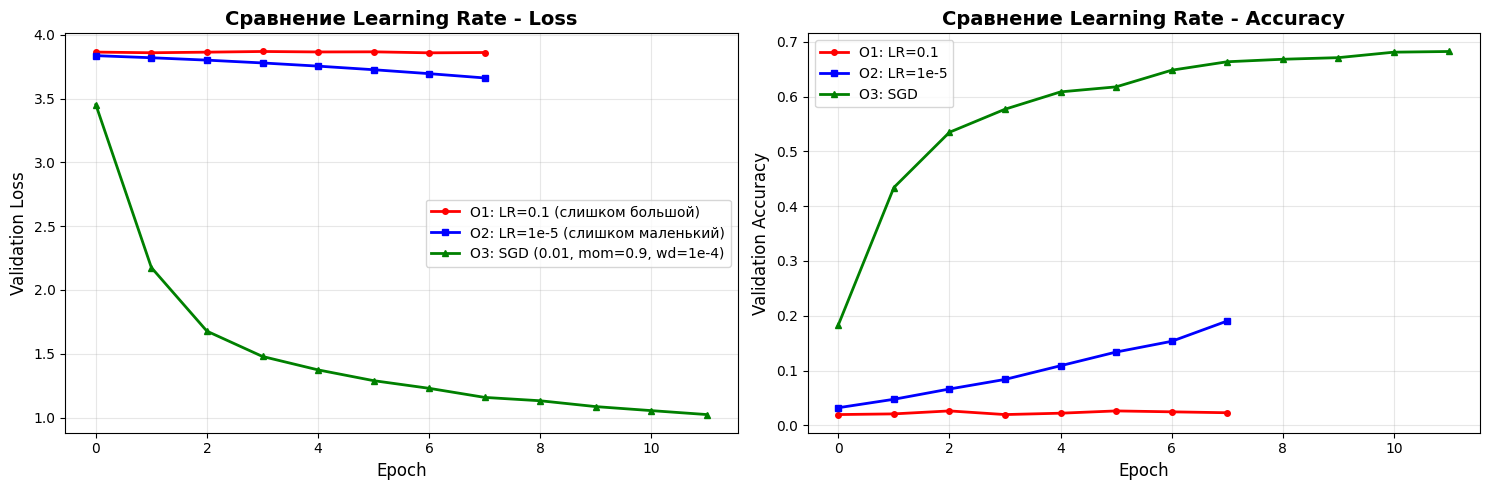

In [106]:
# ============================================
# ЭКСПЕРИМЕНТ O1: Слишком большой Learning Rate (lr=0.1)
# ============================================

print("\n" + "="*50)
print("Эксперимент O1: Слишком большой Learning Rate (lr=0.1)")
print("="*50)

# Создаем модель (та же архитектура, что в E4)
model_o1 = MLP(
    input_shape=(1, 28, 28),
    num_classes=47,
    hidden_sizes=[256, 128],
    activation="relu",
    dropout=0.3,
    use_batchnorm=False
).to(device)

# ОПАСНО: очень большой learning rate
optimizer = optim.Adam(model_o1.parameters(), lr=0.1)
criterion = nn.CrossEntropyLoss()

# История обучения
history_o1 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

# Обучаем всего 8 эпох
EPOCHS_O = 8
for epoch in range(1, EPOCHS_O + 1):
    train_loss, train_acc = train_one_epoch(model_o1, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model_o1, val_loader, criterion, device)

    history_o1['train_loss'].append(train_loss)
    history_o1['train_acc'].append(train_acc)
    history_o1['val_loss'].append(val_loss)
    history_o1['val_acc'].append(val_acc)

    print(f"Эпоха {epoch:2d}/{EPOCHS_O} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

# Сохраняем результаты
run_data_o1 = {
    'experiment_id': 'O1',
    'dataset': 'EMNIST_BALANCED',
    'seed': 42,
    'model_summary': 'hidden=[256,128], relu, dropout=0.3',
    'optimizer': 'Adam',
    'lr': 0.1,
    'momentum': '',
    'weight_decay': 0.0,
    'epochs_trained': EPOCHS_O,
    'best_val_accuracy': f"{max(history_o1['val_acc']):.4f}",
    'best_val_loss': f"{min(history_o1['val_loss']):.4f}"
}
save_run_to_csv(run_data_o1)

# ============================================
# ЭКСПЕРИМЕНТ O2: Слишком маленький Learning Rate (lr=1e-5)
# ============================================

print("\n" + "="*50)
print("Эксперимент O2: Слишком маленький Learning Rate (lr=1e-5)")
print("="*50)

model_o2 = MLP(
    input_shape=(1, 28, 28),
    num_classes=47,
    hidden_sizes=[256, 128],
    activation="relu",
    dropout=0.3,
    use_batchnorm=False
).to(device)

# ОЧЕНЬ маленький learning rate
optimizer = optim.Adam(model_o2.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()

history_o2 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, EPOCHS_O + 1):
    train_loss, train_acc = train_one_epoch(model_o2, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model_o2, val_loader, criterion, device)

    history_o2['train_loss'].append(train_loss)
    history_o2['train_acc'].append(train_acc)
    history_o2['val_loss'].append(val_loss)
    history_o2['val_acc'].append(val_acc)

    print(f"Эпоха {epoch:2d}/{EPOCHS_O} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

run_data_o2 = {
    'experiment_id': 'O2',
    'dataset': 'EMNIST_BALANCED',
    'seed': 42,
    'model_summary': 'hidden=[256,128], relu, dropout=0.3',
    'optimizer': 'Adam',
    'lr': 1e-5,
    'momentum': '',
    'weight_decay': 0.0,
    'epochs_trained': EPOCHS_O,
    'best_val_accuracy': f"{max(history_o2['val_acc']):.4f}",
    'best_val_loss': f"{min(history_o2['val_loss']):.4f}"
}
save_run_to_csv(run_data_o2)

# ============================================
# ЭКСПЕРИМЕНТ O3: SGD с momentum и weight decay
# ============================================

print("\n" + "="*50)
print("Эксперимент O3: SGD + Momentum (0.9) + Weight Decay (1e-4)")
print("="*50)

model_o3 = MLP(
    input_shape=(1, 28, 28),
    num_classes=47,
    hidden_sizes=[256, 128],
    activation="relu",
    dropout=0.3,
    use_batchnorm=False
).to(device)

# SGD с momentum и weight decay
optimizer = optim.SGD(model_o3.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

history_o3 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

EPOCHS_O3 = 12
for epoch in range(1, EPOCHS_O3 + 1):
    train_loss, train_acc = train_one_epoch(model_o3, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model_o3, val_loader, criterion, device)

    history_o3['train_loss'].append(train_loss)
    history_o3['train_acc'].append(train_acc)
    history_o3['val_loss'].append(val_loss)
    history_o3['val_acc'].append(val_acc)

    print(f"Эпоха {epoch:2d}/{EPOCHS_O3} | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

run_data_o3 = {
    'experiment_id': 'O3',
    'dataset': 'EMNIST_BALANCED',
    'seed': 42,
    'model_summary': 'hidden=[256,128], relu, dropout=0.3',
    'optimizer': 'SGD',
    'lr': 0.01,
    'momentum': 0.9,
    'weight_decay': 1e-4,
    'epochs_trained': EPOCHS_O3,
    'best_val_accuracy': f"{max(history_o3['val_acc']):.4f}",
    'best_val_loss': f"{min(history_o3['val_loss']):.4f}"
}
save_run_to_csv(run_data_o3)

print("\n" + "="*50)
print("Создание графика curves_lr_extremes.png")
print("="*50)

import os
from google.colab import files

# Создаем временную папку для графиков (если нет)
temp_dir = Path("/content/temp_figures")
temp_dir.mkdir(parents=True, exist_ok=True)

# Создаем график
plt.figure(figsize=(15, 5))

# График loss
plt.subplot(1, 2, 1)
plt.plot(history_o1['val_loss'], 'r-', label='O1: LR=0.1 (слишком большой)', linewidth=2, marker='o', markersize=4)
plt.plot(history_o2['val_loss'], 'b-', label='O2: LR=1e-5 (слишком маленький)', linewidth=2, marker='s', markersize=4)
plt.plot(history_o3['val_loss'], 'g-', label='O3: SGD (0.01, mom=0.9, wd=1e-4)', linewidth=2, marker='^', markersize=4)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Loss', fontsize=12)
plt.title('Сравнение Learning Rate - Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# График accuracy
plt.subplot(1, 2, 2)
plt.plot(history_o1['val_acc'], 'r-', label='O1: LR=0.1', linewidth=2, marker='o', markersize=4)
plt.plot(history_o2['val_acc'], 'b-', label='O2: LR=1e-5', linewidth=2, marker='s', markersize=4)
plt.plot(history_o3['val_acc'], 'g-', label='O3: SGD', linewidth=2, marker='^', markersize=4)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('Сравнение Learning Rate - Accuracy', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()

# Сохраняем локально в Colab
local_path_lr = '/content/curves_lr_extremes.png'
plt.savefig(local_path_lr, dpi=150, bbox_inches='tight', facecolor='white')
print(f"\nГрафик сохранен локально: {local_path_lr}")
print(f"Размер файла: {os.path.getsize(local_path_lr) / 1024:.1f} KB")

# Скачиваем на компьютер
print("Скачивание файла curves_lr_extremes.png...")
files.download(local_path_lr)

# Показываем график
plt.show()


* Визуализация LR экспериментов

# Финальное тестирование лучшей модели и сохранение конфига

In [107]:
import json
from datetime import datetime

print("\n" + "="*50)
print("Финальное тестирование лучшей модели (E4) на тестовой выборке")
print("="*50)

# Загружаем лучшую модель
best_model = MLP(
    input_shape=(1, 28, 28),
    num_classes=47,
    hidden_sizes=[256, 128],
    activation="relu",
    dropout=0.3,
    use_batchnorm=False
).to(device)

# Загружаем сохраненные веса
best_model.load_state_dict(torch.load(artifacts_dir / 'best_model.pt'))
print("Лучшая модель загружена из best_model.pt")

# Тестируем на test_loader
criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)

print(f"\n{'='*50}")
print(f"РЕЗУЛЬТАТ НА ТЕСТОВОЙ ВЫБОРКЕ:")
print(f"{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"{'='*50}")

# Сохраняем конфигурацию лучшей модели
best_config = {
    'model_name': 'MLP',
    'dataset': 'EMNIST_BALANCED',
    'input_shape': [1, 28, 28],
    'num_classes': 47,
    'hidden_sizes': [256, 128],
    'activation': 'relu',
    'dropout': 0.3,
    'use_batchnorm': False,
    'optimizer': 'Adam',
    'learning_rate': 0.001,
    'early_stopping_patience': 5,
    'early_stopping_min_delta': 0.001,
    'best_epoch': best_epoch_e4,
    'best_val_accuracy': best_val_acc_e4,
    'best_val_loss': best_val_loss_e4,
    'test_accuracy': test_acc,
    'test_loss': test_loss,
    'seed': 42,
    'training_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

# Сохраняем в JSON
config_path = artifacts_dir / 'best_config.json'
with open(config_path, 'w') as f:
    json.dump(best_config, f, indent=4)

print(f"\nКонфигурация лучшей модели сохранена в {config_path}")

# Выводим содержимое конфига для проверки
print("\nСодержимое best_config.json:")
print(json.dumps(best_config, indent=2))


Финальное тестирование лучшей модели (E4) на тестовой выборке
Лучшая модель загружена из best_model.pt

РЕЗУЛЬТАТ НА ТЕСТОВОЙ ВЫБОРКЕ:
Test Loss: 0.8040
Test Accuracy: 0.7563 (75.63%)

Конфигурация лучшей модели сохранена в /content/drive/MyDrive/Colab Notebooks/HW08-09/artifacts/best_config.json

Содержимое best_config.json:
{
  "model_name": "MLP",
  "dataset": "EMNIST_BALANCED",
  "input_shape": [
    1,
    28,
    28
  ],
  "num_classes": 47,
  "hidden_sizes": [
    256,
    128
  ],
  "activation": "relu",
  "dropout": 0.3,
  "use_batchnorm": false,
  "optimizer": "Adam",
  "learning_rate": 0.001,
  "early_stopping_patience": 5,
  "early_stopping_min_delta": 0.001,
  "best_epoch": 19,
  "best_val_accuracy": 0.7508333333333334,
  "best_val_loss": 0.8102878340085348,
  "test_accuracy": 0.7563333333333333,
  "test_loss": 0.8039755474726359,
  "seed": 42,
  "training_date": "2026-03-11 13:59:50"
}


# Просмотр итоговой таблицы результатов

In [108]:
import pandas as pd

print("\n" + "="*60)
print("ИТОГОВАЯ ТАБЛИЦА ВСЕХ ЭКСПЕРИМЕНТОВ")
print("="*60)

# Читаем CSV файл
runs_df = pd.read_csv(artifacts_dir / 'runs.csv')
print(runs_df.to_string(index=False))

print("\n" + "="*60)
print("СТАТИСТИКА ЭКСПЕРИМЕНТОВ")
print("="*60)
print(f"Всего экспериментов: {len(runs_df)}")
print(f"Лучший результат (val_acc): {runs_df['best_val_accuracy'].max()}")
print(f"Худший результат (val_acc): {runs_df['best_val_accuracy'].min()}")
print(f"Средний результат (val_acc): {runs_df['best_val_accuracy'].astype(float).mean():.4f}")

# Отдельно по группам экспериментов
print("\n" + "="*60)
print("РЕГУЛЯРИЗАЦИЯ (E1-E4):")
print("="*60)
reg_exp = runs_df[runs_df['experiment_id'].str.contains('E')]
print(reg_exp[['experiment_id', 'model_summary', 'best_val_accuracy']].to_string(index=False))

print("\n" + "="*60)
print("ОПТИМИЗАЦИЯ (O1-O3):")
print("="*60)
opt_exp = runs_df[runs_df['experiment_id'].str.contains('O')]
print(opt_exp[['experiment_id', 'optimizer', 'lr', 'momentum', 'weight_decay', 'best_val_accuracy']].to_string(index=False))


ИТОГОВАЯ ТАБЛИЦА ВСЕХ ЭКСПЕРИМЕНТОВ
experiment_id         dataset  seed                                                        model_summary optimizer      lr  momentum  weight_decay  epochs_trained  best_val_accuracy  best_val_loss
           E1          KMNIST    42                 hidden=[256,128], relu, dropout=0.0, batchnorm=False      Adam 0.00100       NaN        0.0000              15             0.7325         0.8854
           E2 EMNIST_BALANCED    42                 hidden=[256,128], relu, dropout=0.3, batchnorm=False      Adam 0.00100       NaN        0.0000              15             0.7271         0.8451
           E3 EMNIST_BALANCED    42                  hidden=[256,128], relu, dropout=0.0, batchnorm=True      Adam 0.00100       NaN        0.0000              15             0.7621         0.7632
           E4 EMNIST_BALANCED    42 hidden=[256,128], relu, dropout=0.3, batchnorm=False, early_stopping      Adam 0.00100       NaN        0.0000              22             

# Скачивание csv файла

In [109]:
# Скачиваем CSV
csv_path = artifacts_dir / 'runs.csv'
if csv_path.exists():
    print(f"CSV файл найден: {csv_path}")
    print(f"Размер: {csv_path.stat().st_size / 1024:.2f} KB")
    from google.colab import files
    files.download(str(csv_path))
    print("CSV файл скачивается...")
else:
    print(f"CSV файл не найден")

CSV файл найден: /content/drive/MyDrive/Colab Notebooks/HW08-09/artifacts/runs.csv
Размер: 7.09 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

CSV файл скачивается...


In [110]:
# ============================================
# СКАЧИВАНИЕ ВСЕХ ФАЙЛОВ НА КОМПЬЮТЕР
# ============================================

from google.colab import files

# Список файлов для скачивания
files_to_download = [
    (local_artifacts_dir / 'best_model.pt', 'best_model.pt'),
    (local_artifacts_dir / 'best_config.json', 'best_config.json'),
    (local_artifacts_dir / 'history_e4.pkl', 'history_e4.pkl'),
    (local_figures_dir / 'curves_best.png', 'curves_best.png')
]

for file_path, file_name in files_to_download:
    if file_path.exists():
        print(f"Скачивание {file_name}...")
        files.download(str(file_path))
    else:
        print(f"Файл не найден: {file_path}")

print("\nВсе файлы скачаны!")

Скачивание best_model.pt...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Скачивание best_config.json...


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Скачивание curves_best.png...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Все файлы скачаны!
